# Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV

In [13]:
df = pd.read_csv(r"C:\Users\LENOVO\Downloads\Amazon Sales data.csv")
df.head()

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit
0,Australia and Oceania,Tuvalu,Baby Food,Offline,H,5/28/2010,669165933,6/27/2010,9925,255.28,159.42,2533654.00,1582243.50,951410.50
1,Central America and the Caribbean,Grenada,Cereal,Online,C,8/22/2012,963881480,9/15/2012,2804,205.70,117.11,576782.80,328376.44,248406.36
2,Europe,Russia,Office Supplies,Offline,L,5/2/2014,341417157,5/8/2014,1779,651.21,524.96,1158502.59,933903.84,224598.75
3,Sub-Saharan Africa,Sao Tome and Principe,Fruits,Online,C,6/20/2014,514321792,7/5/2014,8102,9.33,6.92,75591.66,56065.84,19525.82
4,Sub-Saharan Africa,Rwanda,Office Supplies,Offline,L,2/1/2013,115456712,2/6/2013,5062,651.21,524.96,3296425.02,2657347.52,639077.50


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Region          100 non-null    object 
 1   Country         100 non-null    object 
 2   Item Type       100 non-null    object 
 3   Sales Channel   100 non-null    object 
 4   Order Priority  100 non-null    object 
 5   Order Date      100 non-null    object 
 6   Order ID        100 non-null    int64  
 7   Ship Date       100 non-null    object 
 8   Units Sold      100 non-null    int64  
 9   Unit Price      100 non-null    float64
 10  Unit Cost       100 non-null    float64
 11  Total Revenue   100 non-null    float64
 12  Total Cost      100 non-null    float64
 13  Total Profit    100 non-null    float64
dtypes: float64(5), int64(2), object(7)
memory usage: 11.1+ KB


In [5]:
df.describe()

,Order ID,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit
count,1.000000e+02,100.000000,100.000000,100.000000,1.000000e+02,1.000000e+02,1.000000e+02
mean,5.550204e+08,5128.710000,276.761300,191.048000,1.373488e+06,9.318057e+05,4.416820e+05
std,2.606153e+08,2794.484562,235.592241,188.208181,1.460029e+06,1.083938e+06,4.385379e+05
min,1.146066e+08,124.000000,9.330000,6.920000,4.870260e+03,3.612240e+03,1.258020e+03
25%,3.389225e+08,2836.250000,81.730000,35.840000,2.687212e+05,1.688680e+05,1.214436e+05
50%,5.577086e+08,5382.500000,179.880000,107.275000,7.523144e+05,3.635664e+05,2.907680e+05
75%,7.907551e+08,7369.000000,437.200000,263.330000,2.212045e+06,1.613870e+06,6.358288e+05
max,9.940222e+08,9925.000000,668.270000,524.960000,5.997055e+06,4.509794e+06,1.719922e+06


# Total Revenue

In [7]:
total_revenue = df["Total Revenue"].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 137348768.31


# Revenue by Product

In [14]:
product_sales = df.groupby("Item Type")["Total Revenue"].sum()
print(product_sales)

Item Type
Baby Food          10350327.60
Beverages           2690794.60
Cereal              5322898.90
Clothes             7787292.80
Cosmetics          36601509.60
Fruits               466481.34
Household          29889712.29
Meat                4503675.75
Office Supplies    30585380.07
Personal Care       3980904.84
Snacks              2080733.46
Vegetables          3089057.06
Name: Total Revenue, dtype: float64


# Revenue by Region

In [15]:
region_sales = df.groupby("Region")["Total Revenue"].sum()
print(region_sales)

Region
Asia                                 21347091.02
Australia and Oceania                14094265.13
Central America and the Caribbean     9170385.49
Europe                               33368932.11
Middle East and North Africa         14052706.58
North America                         5643356.55
Sub-Saharan Africa                   39672031.43
Name: Total Revenue, dtype: float64


# Best Selling Category

In [11]:
category_sales = df.groupby("Item Type")["Units Sold"].sum()
print(category_sales.sort_values(ascending=False))

Item Type
Cosmetics          83718
Clothes            71260
Beverages          56708
Fruits             49998
Personal Care      48708
Office Supplies    46967
Household          44727
Baby Food          40545
Cereal             25877
Vegetables         20051
Snacks             13637
Meat               10675
Name: Units Sold, dtype: int64


# Bar Chart – Revenue by Product

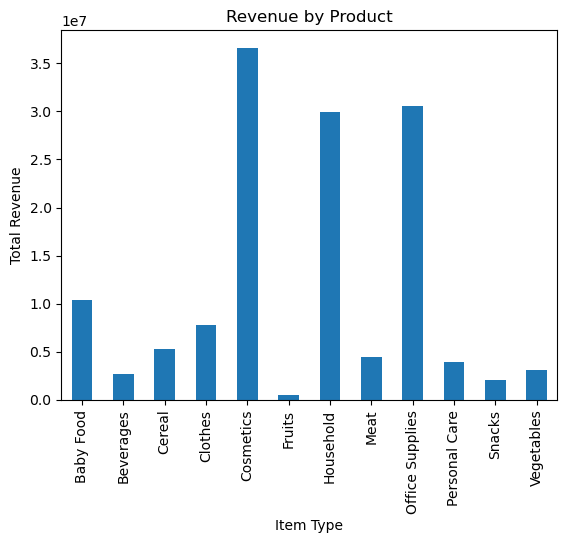

In [16]:
product_sales.plot(kind='bar', title="Revenue by Product")
plt.ylabel("Total Revenue")
plt.show()

# Pie Chart – Sales by Region

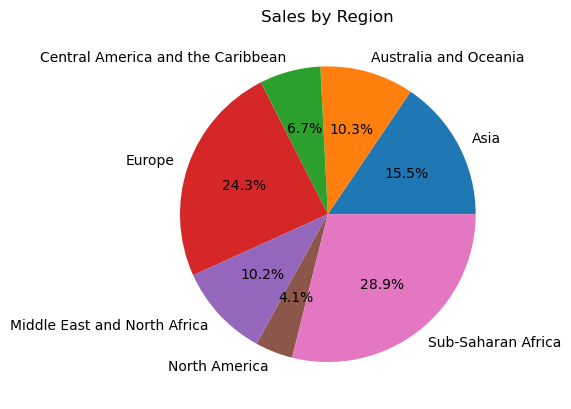

In [17]:
region_sales.plot(kind='pie', autopct='%1.1f%%', title="Sales by Region")
plt.ylabel("")
plt.show()

# Line Chart – Revenue Trend

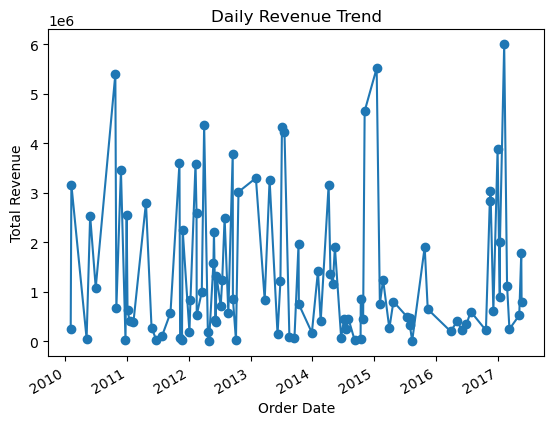

In [19]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
daily_sales = df.groupby("Order Date")["Total Revenue"].sum()

daily_sales.plot(kind='line', marker='o', title="Daily Revenue Trend")
plt.ylabel("Total Revenue")
plt.show()